# Module 5 / Class 1 -- K-Means Clustering

**Objectives:**
- Understand K-Means algorithm step by step
- Perform K-Means by hand on a small dataset
- Verify results with scikit-learn
- Use the Elbow Method and Silhouette Score to choose k

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)

## 1. Our Dataset -- 6 Points in 2D

We use a tiny dataset so you can follow every step on paper.

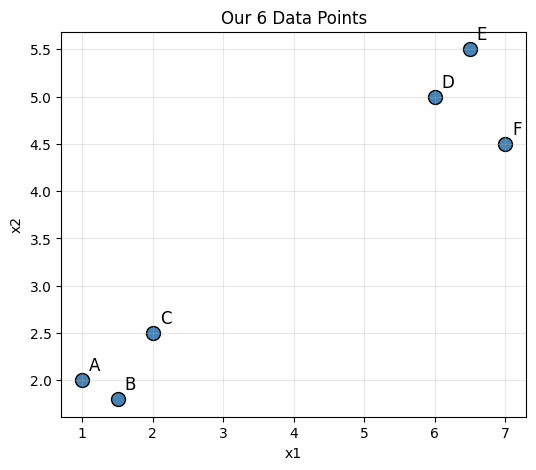

In [2]:
# 6 points that form two natural clusters
X = np.array([
    [1.0, 2.0],   # A
    [1.5, 1.8],   # B
    [2.0, 2.5],   # C
    [6.0, 5.0],   # D
    [6.5, 5.5],   # E
    [7.0, 4.5],   # F
])

labels = ['A', 'B', 'C', 'D', 'E', 'F']

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=100, c='steelblue', edgecolors='black')
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (X[i, 0] + 0.1, X[i, 1] + 0.1), fontsize=12)
plt.title('Our 6 Data Points')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Manual K-Means Walkthrough (k=2)

### How K-Means works:
1. **Initialize** k centroids (pick k random points or use a heuristic)
2. **Assign** each point to the nearest centroid
3. **Update** each centroid to the mean of its assigned points
4. **Repeat** steps 2-3 until centroids stop moving

### Step 0 -- Initialize Centroids

We pick points A and D as our initial centroids.

In [3]:
# Initial centroids: pick A (index 0) and D (index 3)
c1 = X[0].copy()  # [1.0, 2.0]
c2 = X[3].copy()  # [6.0, 5.0]

print(f"Initial centroid 1: {c1}")
print(f"Initial centroid 2: {c2}")

Initial centroid 1: [1. 2.]
Initial centroid 2: [6. 5.]


In [4]:
def euclidean_distance(a, b):
    """Compute Euclidean distance between two points."""
    return np.sqrt(np.sum((a - b) ** 2))


def plot_kmeans_step(X, labels, c1, c2, assignments, step_name):
    """Plot current state of K-Means."""
    colors = ['#e74c3c' if a == 1 else '#3498db' for a in assignments]
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], s=100, c=colors, edgecolors='black')
    plt.scatter(*c1, s=250, c='#3498db', marker='X', edgecolors='black', linewidths=2, label='Centroid 1')
    plt.scatter(*c2, s=250, c='#e74c3c', marker='X', edgecolors='black', linewidths=2, label='Centroid 2')
    for i, lbl in enumerate(labels):
        plt.annotate(lbl, (X[i, 0] + 0.1, X[i, 1] + 0.1), fontsize=12)
    plt.title(step_name)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Iteration 1 -- Assign + Update

Point | Dist to C1 | Dist to C2 | Assigned to
--------------------------------------------------
  A   |   0.000    |   5.831    | Cluster 1
  B   |   0.539    |   5.522    | Cluster 1
  C   |   1.118    |   4.717    | Cluster 1
  D   |   5.831    |   0.000    | Cluster 2
  E   |   6.519    |   0.707    | Cluster 2
  F   |   6.500    |   1.118    | Cluster 2


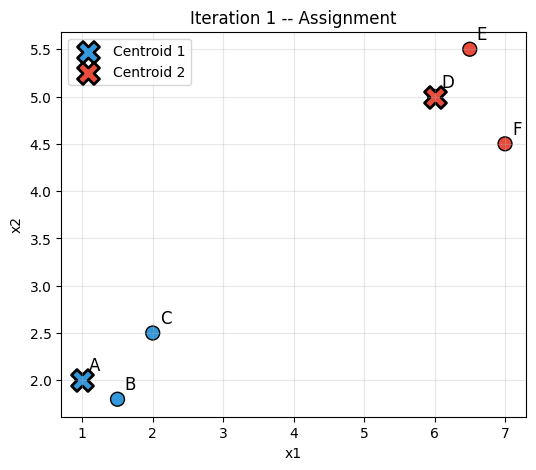

In [5]:
# ASSIGN: compute distance from each point to both centroids
assignments = []
print("Point | Dist to C1 | Dist to C2 | Assigned to")
print("-" * 50)
for i in range(len(X)):
    d1 = euclidean_distance(X[i], c1)
    d2 = euclidean_distance(X[i], c2)
    cluster = 0 if d1 <= d2 else 1
    assignments.append(cluster)
    print(f"  {labels[i]}   |   {d1:.3f}    |   {d2:.3f}    | Cluster {cluster + 1}")

plot_kmeans_step(X, labels, c1, c2, assignments, 'Iteration 1 -- Assignment')

Old centroid 1: [1. 2.] -> New centroid 1: [1.5 2.1]
Old centroid 2: [6. 5.] -> New centroid 2: [6.5 5. ]


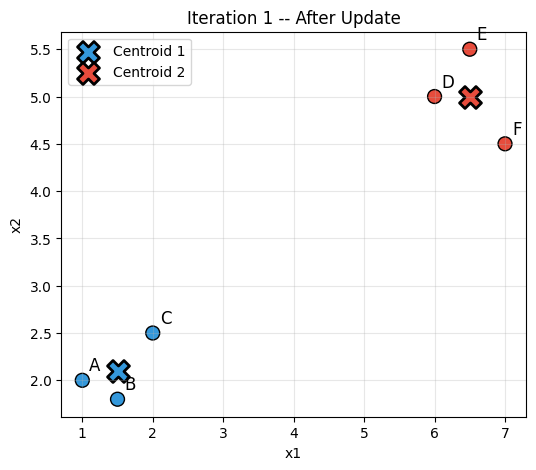

In [6]:
# UPDATE: compute new centroids as mean of assigned points
cluster_1_points = X[np.array(assignments) == 0]
cluster_2_points = X[np.array(assignments) == 1]

c1_new = cluster_1_points.mean(axis=0)
c2_new = cluster_2_points.mean(axis=0)

print(f"Old centroid 1: {c1} -> New centroid 1: {c1_new}")
print(f"Old centroid 2: {c2} -> New centroid 2: {c2_new}")

c1 = c1_new
c2 = c2_new

plot_kmeans_step(X, labels, c1, c2, assignments, 'Iteration 1 -- After Update')

### Iteration 2 -- Assign + Update

Point | Dist to C1 | Dist to C2 | Assigned to
--------------------------------------------------
  A   |   0.510    |   6.265    | Cluster 1
  B   |   0.300    |   5.936    | Cluster 1
  C   |   0.640    |   5.148    | Cluster 1
  D   |   5.354    |   0.500    | Cluster 2
  E   |   6.046    |   0.500    | Cluster 2
  F   |   6.001    |   0.707    | Cluster 2

Assignments unchanged -- K-Means has converged!


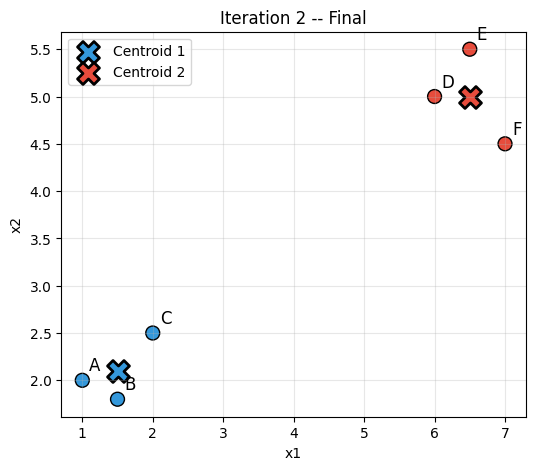

In [7]:
# ASSIGN again with new centroids
assignments_new = []
print("Point | Dist to C1 | Dist to C2 | Assigned to")
print("-" * 50)
for i in range(len(X)):
    d1 = euclidean_distance(X[i], c1)
    d2 = euclidean_distance(X[i], c2)
    cluster = 0 if d1 <= d2 else 1
    assignments_new.append(cluster)
    print(f"  {labels[i]}   |   {d1:.3f}    |   {d2:.3f}    | Cluster {cluster + 1}")

# Check convergence
if assignments_new == assignments:
    print("\nAssignments unchanged -- K-Means has converged!")
else:
    print("\nAssignments changed -- another iteration needed.")
    assignments = assignments_new

    cluster_1_points = X[np.array(assignments) == 0]
    cluster_2_points = X[np.array(assignments) == 1]
    c1 = cluster_1_points.mean(axis=0)
    c2 = cluster_2_points.mean(axis=0)

plot_kmeans_step(X, labels, c1, c2, assignments_new, 'Iteration 2 -- Final')

## 3. Verify with scikit-learn

In [8]:
kmeans = KMeans(n_clusters=2, init=np.array([[1.0, 2.0], [6.0, 5.0]]), n_init=1, random_state=42)
kmeans.fit(X)

print("sklearn labels:", kmeans.labels_)
print("sklearn centroids:")
print(kmeans.cluster_centers_)
print(f"\nInertia (within-cluster sum of squares): {kmeans.inertia_:.4f}")

sklearn labels: [0 0 0 1 1 1]
sklearn centroids:
[[1.5 2.1]
 [6.5 5. ]]

Inertia (within-cluster sum of squares): 1.7600


## 4. Elbow Method -- Choosing k

We generate a slightly larger dataset and test k from 2 to 6.

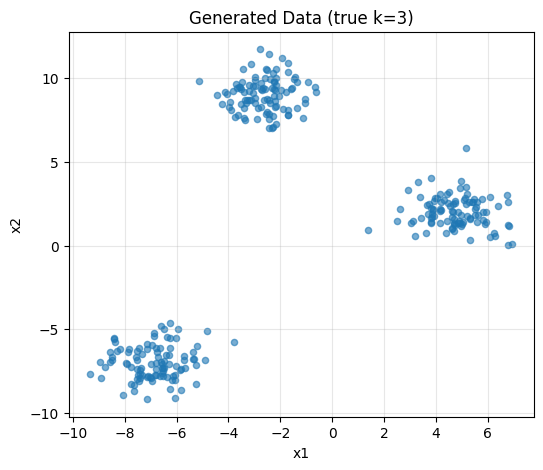

In [9]:
from sklearn.datasets import make_blobs

# Generate data with 3 natural clusters
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=20, alpha=0.6)
plt.title('Generated Data (true k=3)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
K_range = range(2, 7)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blobs, km.labels_))
    print(f"k={k}  |  Inertia: {km.inertia_:.1f}  |  Silhouette: {sil_scores[-1]:.4f}")

k=2  |  Inertia: 5763.5  |  Silhouette: 0.7049
k=3  |  Inertia: 566.9  |  Silhouette: 0.8480
k=4  |  Inertia: 496.4  |  Silhouette: 0.6637
k=5  |  Inertia: 427.1  |  Silhouette: 0.4901
k=6  |  Inertia: 375.0  |  Silhouette: 0.5168


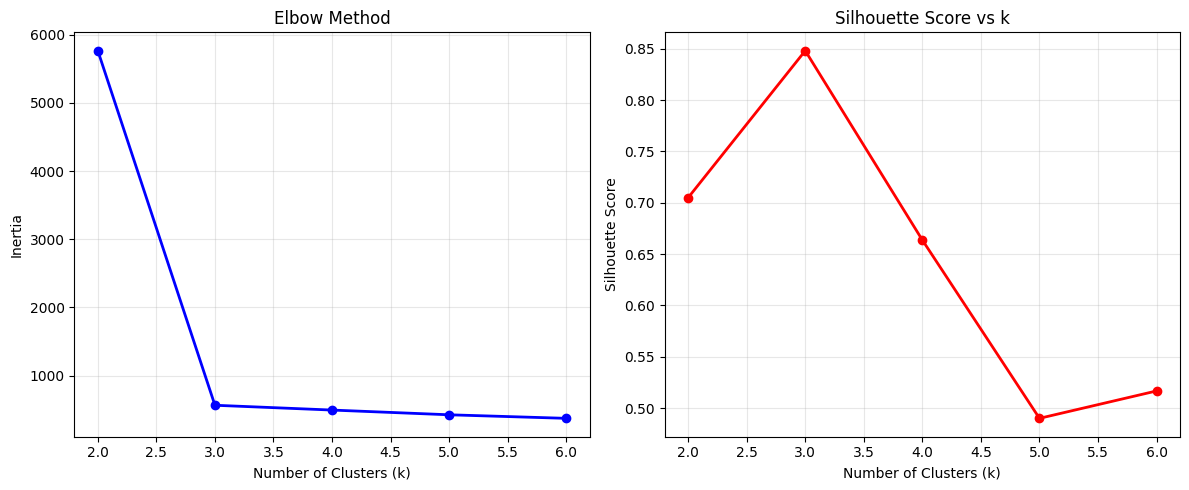

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(K_range), sil_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Interpreting Results

- **Elbow Method**: Look for the "elbow" -- the point where adding more clusters gives diminishing returns in inertia reduction.
- **Silhouette Score**: Ranges from -1 to 1. Higher is better. The peak indicates the best k.
- Both metrics should agree (or at least be close). For this data, k=3 should be the clear winner.

---

## TODO: Student Work

### Task 1 -- Document your manual K-Means computation

In the cells below, write out (in your own words):
1. The distance calculations you performed by hand for each iteration
2. Which cluster each point was assigned to
3. How you computed the new centroids
4. When and why the algorithm converged

# TODO: Write your manual computation steps here

**Iteration 1:**
- Initial centroids: C1=(1,2), C2=(9,7)
- Distance calculations:
  A(1,2):     dist to C1=0.00,  dist to C2=10.63 → Cluster 1
  B(2,1):     dist to C1=1.41,  dist to C2=9.22  → Cluster 1
  C(1.5,1.5): dist to C1=0.71,  dist to C2=9.90  → Cluster 1
  D(8,8):     dist to C1=9.90,  dist to C2=1.41  → Cluster 2
  E(9,7):     dist to C1=10.63, dist to C2=0.00  → Cluster 2
  F(8.5,8.5): dist to C1=10.61, dist to C2=1.58  → Cluster 2
- New C1 = mean of A,B,C = (1.5, 1.5)
- New C2 = mean of D,E,F = (8.5, 7.83)


**Iteration 2:**
- Recomputed distances with updated centroids
- All assignments remained the same as Iteration 1

**Convergence:**
- The algorithm converged after Iteration 2 because
  no point changed its cluster assignment.
  Centroids stopped moving, so the algorithm terminated.


### Task 2 -- Interpret the elbow and silhouette plots

Answer these questions:
1. What value of k does the elbow method suggest?
2. What value of k gives the highest silhouette score?
3. Do the two methods agree?

# TODO: Write your answers here

1. The elbow method suggests k=3, because the inertia
   drops sharply from k=2 to k=3, then flattens out.

2. The silhouette score is highest at k=3, confirming
   that 3 clusters best separate the data.

3. Yes, both methods agree — k=3 is the optimal number
   of clusters for this dataset, which matches the
   3 natural groups visible in the scatter plot.